<h2 align="center">STAGE MIDL 2 - HELENA CROS ET ELOISE SALLET</h2>

Ce projet porte sur le challenge AssurPrime organisé par Crédit Agricole Assurances. L'objectif est d'identifier le modèle le plus performant pour prédire la prime pure liée au risque incendie au sein du contrat multirisque agricole.

La variable cible finale, appelée charge, est calculée comme le produit de la fréquence prédite, du coût moyen estimé et de la variable d'exposition `ANNEE_ASSURANCE`. Le jeu de données comprend plus de 300 variables couvrant des dimensions géographiques, météorologiques et des spécificités techniques propres aux contrats.

Dans ce notebook, nous allons :
1. Modéliser la charge avec **gradient boosting (LightGBM)** via deux modèles séparés (fréquence et coût moyen)
2. Compléter cette approche avec un **réseau de neurones simple**
3. Calculer le **disparate impact** pour évaluer l'équité du modèle

### Imports et chargement des données

In [2]:
import warnings

import numpy as np
import pandas as pd
import lightgbm as lgb
import tensorflow as tf

from category_encoders import CountEncoder
from ctgan import CTGAN

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.utils.class_weight import compute_class_weight

from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

pd.set_option('display.max_columns', 375)
warnings.filterwarnings('ignore')

In [3]:
# Chargement des données
print("Chargement des données...")
X_train_raw = pd.read_csv("train_input.csv")
y_train = pd.read_csv("train_output.csv")
X_test  = pd.read_csv("test_input.csv")
print("Données chargées avec succès.")

print("\nAperçu de X_train :")
display(X_train_raw.head())
print("Aperçu de y_train :")
display(y_train.head())

print(f"Dimensions de X_train : {X_train_raw.shape}")
print(f"Dimensions de y_train : {y_train.shape}")
print(f"Dimensions de X_test  : {X_test.shape}")

Chargement des données...
Données chargées avec succès.

Aperçu de X_train :


,ID,ACTIVIT2,VOCATION,TYPERS,ANCIENNETE,ADOSS,CARACT1,CARACT2,CARACT3,INDEM1,DUREE_REQANEUF,CARACT4,CARACT5,TYPBAT1,INDEM2,TYPBAT2,FRCH1,FRCH2,DEROG1,DEROG2,DEROG3,DEROG4,DEROG5,DEROG6,DEROG7,DEROG8,DEROG9,DEROG10,DEROG11,DEROG12,DEROG13,DEROG14,DEROG15,DEROG16,TAILLE1,TAILLE2,CA1,CA2,CA3,KAPITAL1,KAPITAL2,KAPITAL3,KAPITAL4,KAPITAL5,KAPITAL6,KAPITAL7,KAPITAL8,KAPITAL9,KAPITAL10,KAPITAL11,KAPITAL12,KAPITAL13,KAPITAL14,KAPITAL15,KAPITAL16,KAPITAL17,KAPITAL18,KAPITAL19,KAPITAL20,KAPITAL21,KAPITAL22,KAPITAL23,KAPITAL24,KAPITAL25,KAPITAL26,KAPITAL27,KAPITAL28,KAPITAL29,KAPITAL30,KAPITAL31,KAPITAL32,KAPITAL33,KAPITAL34,KAPITAL35,KAPITAL36,KAPITAL37,KAPITAL38,KAPITAL39,KAPITAL40,KAPITAL41,KAPITAL42,KAPITAL43,SURFACE1,SURFACE2,SURFACE3,SURFACE4,SURFACE5,SURFACE6,SURFACE7,SURFACE8,SURFACE9,SURFACE10,SURFACE11,SURFACE12,SURFACE13,SURFACE14,SURFACE15,SURFACE16,SURFACE17,SURFACE18,SURFACE19,SURFACE20,SURFACE21,NBBAT1,NBBAT2,NBBAT3,NBBAT4,NBBAT5,NBBAT6,NBBAT7,NBBAT8,NBBAT9,NBBAT10,NBBAT11,NBBAT13,NBBAT14,TAILLE3,TAILLE4,NBSINCONJ,NBSINSTRT,COEFASS,RISK1,RISK2,RISK3,RISK4,RISK5,RISK6,RISK7,RISK8,RISK9,RISK10,RISK11,RISK12,RISK13,EQUIPEMENT1,EQUIPEMENT2,EQUIPEMENT3,EQUIPEMENT4,EQUIPEMENT5,EQUIPEMENT6,EQUIPEMENT7,DISTANCE_111,DISTANCE_112,DISTANCE_121,DISTANCE_122,DISTANCE_123,DISTANCE_124,DISTANCE_131,DISTANCE_132,DISTANCE_133,DISTANCE_141,DISTANCE_142,DISTANCE_211,DISTANCE_212,DISTANCE_213,DISTANCE_221,DISTANCE_222,DISTANCE_223,DISTANCE_231,DISTANCE_242,DISTANCE_243,DISTANCE_244,DISTANCE_311,DISTANCE_312,DISTANCE_313,DISTANCE_321,DISTANCE_322,DISTANCE_323,DISTANCE_324,DISTANCE_331,DISTANCE_332,DISTANCE_333,DISTANCE_334,DISTANCE_335,DISTANCE_411,DISTANCE_412,DISTANCE_421,DISTANCE_422,DISTANCE_423,DISTANCE_511,DISTANCE_512,DISTANCE_521,DISTANCE_522,DISTANCE_523,PROPORTION_11,PROPORTION_12,PROPORTION_13,PROPORTION_14,PROPORTION_21,PROPORTION_22,PROPORTION_23,PROPORTION_24,PROPORTION_31,PROPORTION_32,PROPORTION_33,PROPORTION_41,PROPORTION_42,PROPORTION_51,PROPORTION_52,MEN,MEN_PAUV,MEN_1IND,MEN_5IND,MEN_PROP,MEN_FMP,MEN_COLL,MEN_MAIS,LOG_AVA1,LOG_A1_A2,LOG_A2_A3,LOG_APA3,LOG_INC,LOG_SOC,IND,IND_0_Y1,IND_Y1_Y2,IND_Y2_Y3,IND_Y3_Y4,IND_Y4_Y5,IND_Y5_Y6,IND_Y6_Y7,IND_Y7_Y8,IND_Y8_Y9,IND_Y9,IND_INC,IND_SNV,MEN_SURF,DISTANCE_1,DISTANCE_2,ALTITUDE_1,ALTITUDE_2,ALTITUDE_3,ALTITUDE_4,ALTITUDE_5,BDTOPO_BAT_MAX_HAUTEUR_MAX,HAUTEUR,HAUTEUR_MAX,BDTOPO_BAT_MAX_HAUTEUR,ZONE_VENT,NB_CASERNES,NBJTX25_MM_A,NBJTX25_MMAX_A,NBJTX25_MSOM_A,NBJTX0_MM_A,NBJTX0_MMAX_A,NBJTX0_MSOM_A,NBJTXI27_MM_A,NBJTXI27_MMAX_A,NBJTXI27_MSOM_A,NBJTXS32_MM_A,NBJTXS32_MMAX_A,NBJTXS32_MSOM_A,NBJTXI20_MM_A,NBJTXI20_MMAX_A,NBJTXI20_MSOM_A,NBJTX30_MM_A,NBJTX30_MMAX_A,NBJTX30_MSOM_A,NBJTX35_MM_A,NBJTX35_MMAX_A,NBJTX35_MSOM_A,NBJTN10_MM_A,NBJTN10_MMAX_A,NBJTN10_MSOM_A,NBJTNI10_MM_A,NBJTNI10_MMAX_A,NBJTNI10_MSOM_A,NBJTN5_MM_A,NBJTN5_MMAX_A,NBJTN5_MSOM_A,NBJTNS25_MM_A,NBJTNS25_MMAX_A,NBJTNS25_MSOM_A,NBJTNI15_MM_A,NBJTNI15_MMAX_A,NBJTNI15_MSOM_A,NBJTNI20_MM_A,NBJTNI20_MMAX_A,NBJTNI20_MSOM_A,NBJTNS20_MM_A,NBJTNS20_MMAX_A,NBJTNS20_MSOM_A,NBJTMS24_MM_A,NBJTMS24_MMAX_A,NBJTMS24_MSOM_A,TAMPLIAB_VOR_MM_A,TAMPLIAB_VOR_MMAX_A,TAMPLIM_VOR_MM_A,TAMPLIM_VOR_MMAX_A,TM_VOR_MM_A,TM_VOR_MMAX_A,TMM_VOR_MM_A,TMM_VOR_MMAX_A,TMMAX_VOR_MM_A,TMMAX_VOR_MMAX_A,TMMIN_VOR_MM_A,TMMIN_VOR_MMAX_A,TN_VOR_MM_A,TN_VOR_MMAX_A,TNAB_VOR_MM_A,TNAB_VOR_MMAX_A,TNMAX_VOR_MM_A,TNMAX_VOR_MMAX_A,TX_VOR_MM_A,TX_VOR_MMAX_A,TXAB_VOR_MM_A,TXAB_VOR_MMAX_A,TXMIN_VOR_MM_A,TXMIN_VOR_MMAX_A,NBJFF10_MM_A,NBJFF10_MMAX_A,NBJFF10_MSOM_A,NBJFF16_MM_A,NBJFF16_MMAX_A,NBJFF16_MSOM_A,NBJFF28_MM_A,NBJFF28_MMAX_A,NBJFF28_MSOM_A,NBJFXI3S10_MM_A,NBJFXI3S10_MMAX_A,NBJFXI3S10_MSOM_A,NBJFXI3S16_MM_A,NBJFXI3S16_MMAX_A,NBJFXI3S16_MSOM_A,NBJFXI3S28_MM_A,NBJFXI3S28_MMAX_A,NBJFXI3S28_MSOM_A,NBJFXY8_MM_A,NBJFXY8_MMAX_A,NBJFXY8_MSOM_A,NBJFXY10_MM_A,NBJFXY10_MMAX_A,NBJFXY10_MSOM_A,NBJFXY15_MM_A,NBJFXY15_MMAX_A,NBJFXY15_MSOM_A,FFM_VOR_MM_A,FFM_VOR_MMAX_A,FXI3SAB_VOR_MM_A,FXI3SAB_VOR_MMAX_A,FXIAB_VOR_MM_A,FXIAB_VOR_MMAX_A,FXYAB_VOR_MM_A,FXYAB_VOR_MMAX_A,FFM_VOR_COM_MM_A_Y

Aperçu de y_train :


,ID,FREQ,CM,ANNEE_ASSURANCE,CHARGE
0,1,0.0,0.0,1.000000,0.0
1,2,0.0,0.0,1.000000,0.0
2,3,0.0,0.0,0.402740,0.0
3,4,0.0,0.0,0.246575,0.0
4,5,0.0,0.0,0.838356,0.0


Dimensions de X_train : (383610, 374)
Dimensions de y_train : (383610, 5)
Dimensions de X_test  : (95852, 374)


### Prétraitement des données

In [4]:
# Traitement des valeurs manquantes
numeric_columns = X_train_raw.select_dtypes(include=['number']).columns
X_train_raw[numeric_columns] = X_train_raw[numeric_columns].fillna(0)

fill_cols = [c for c in X_train_raw.columns if c not in numeric_columns]
X_train_raw[fill_cols] = X_train_raw[fill_cols].fillna(-999)

# Suppression des colonnes inutiles
X_train = X_train_raw.drop(['ID', 'ANNEE_ASSURANCE'], axis=1)

# Encodage des variables catégorielles avec CountEncoder
encoder = CountEncoder(cols=fill_cols)
encoder.fit(X_train)
X_train_enc = encoder.transform(X_train)

In [5]:
# conversion des variables catégorielles pour LightGBM
def prepare_lgbm_data(df):
    df_clean = df.copy()
    cols_texte = df_clean.select_dtypes(include=['object']).columns
    df_clean[cols_texte] = df_clean[cols_texte].astype(str).astype('category')
    return df_clean

X_train_clean = prepare_lgbm_data(X_train)
X_test_clean  = prepare_lgbm_data(X_test)
cat_features  = X_train_clean.select_dtypes(include=['category']).columns.tolist()

print(f"Nombre de variables catégorielles : {len(cat_features)}")

Nombre de variables catégorielles : 280


---
## Méthode 1 : Gradient Boosting avec deux modèles (LightGBM)

Nous modélisons la prime en suivant l'approche actuarielle classique : deux modèles distincts entraînés avec LightGBM.
- **Modèle fréquence** : loi de Poisson qui prédit le nombre de sinistres
- **Modèle coût moyen** : loi Gamma qui prédit le coût conditionnel à l'occurrence d'un sinistre

La charge finale est reconstituée par : `charge = fréquence × coût moyen × exposition`

#### Modèle fréquence (Poisson)

In [11]:
X_tr, X_val, y_tr, y_val = train_test_split(X_train_clean, y_train['FREQ'], test_size=0.2, random_state=42)

train_set = lgb.Dataset(X_tr, label=y_tr, categorical_feature=cat_features)
val_set   = lgb.Dataset(X_val, label=y_val, reference=train_set, categorical_feature=cat_features)

params_freq = {
    'objective': 'poisson', 'metric': 'poisson',
    'learning_rate': 0.005, 'num_leaves': 7,
    'min_data_in_leaf': 1000, 'feature_fraction': 0.3,
    'lambda_l2': 10, 'verbose': -1
}

model_freq = lgb.train(
    params_freq, train_set,
    num_boost_round=2000,
    valid_sets=[train_set, val_set],
    callbacks=[lgb.early_stopping(stopping_rounds=100)]
)

preds_val_freq = model_freq.predict(X_val)
print(f"Somme FREQ réelles  : {np.sum(y_val):.2f}")
print(f"Somme FREQ prédites : {np.sum(preds_val_freq):.2f}")
print(f"Ratio (prédit/réel) : {np.sum(preds_val_freq)/np.sum(y_val):.4f}")

Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[1987]	training's poisson: 0.0566448	valid_1's poisson: 0.0669724
Somme FREQ réelles  : 1074.64
Somme FREQ prédites : 925.87
Ratio (prédit/réel) : 0.8616


#### Modèle coût moyen (Gamma)

In [12]:
# On ne garde que les contrats avec au moins un sinistre
mask_strict = (y_train['FREQ'] > 0) & (y_train['CM'] > 0)
X_cm = X_train_clean[mask_strict]
y_cm = y_train.loc[mask_strict, 'CM']
print(f"Sinistres exploitables pour le modèle Gamma : {len(y_cm)}")

X_tr_cm, X_val_cm, y_tr_cm, y_val_cm = train_test_split(X_cm, y_cm, test_size=0.2, random_state=42)

train_set_cm = lgb.Dataset(X_tr_cm, label=y_tr_cm, categorical_feature=cat_features)
val_set_cm   = lgb.Dataset(X_val_cm, label=y_val_cm, reference=train_set_cm, categorical_feature=cat_features)

params_cm = {
    'objective': 'gamma', 'metric': 'rmse',
    'learning_rate': 0.005, 'num_leaves': 12,
    'min_data_in_leaf': 30, 'feature_fraction': 0.6,
    'lambda_l1': 0.1, 'verbose': -1
}

model_cm = lgb.train(
    params_cm, train_set_cm,
    num_boost_round=3000,
    valid_sets=[train_set_cm, val_set_cm],
    callbacks=[lgb.early_stopping(stopping_rounds=100)]
)

preds_val_cm = model_cm.predict(X_val_cm)

Sinistres exploitables pour le modèle Gamma : 2352
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[224]	training's rmse: 76014.6	valid_1's rmse: 78799.3


#### Soumission LightGBM

In [13]:
cols_train  = model_freq.feature_name()
X_test_final = X_test[cols_train].copy()

for col in X_test_final.columns:
    if X_test_final[col].dtype == 'object' or X_test_final[col].dtype.name == 'category':
        X_test_final[col] = X_test_final[col].astype('category').cat.codes
    X_test_final[col] = X_test_final[col].fillna(-1)

X_test_numpy = X_test_final.values.astype(np.float32)

pred_freq = model_freq.predict(X_test_numpy)
pred_cost = model_cm.predict(X_test_numpy)
expo      = X_test['ANNEE_ASSURANCE']


BIAIS_CORRECTIF = 1 / 0.8616  # ratio calculé sur ta validation
charge_lgbm = pred_freq * BIAIS_CORRECTIF * pred_cost * expo

submission1_lgbm = pd.DataFrame({'ID': X_test['ID'], 'CHARGE': charge_lgbm})
submission1_lgbm['CHARGE'] = submission1_lgbm['CHARGE'].clip(upper=y_train['CHARGE'].max() * 1.2)
submission1_lgbm['CHARGE'] = submission1_lgbm['CHARGE'].fillna(y_train['CHARGE'].mean())
submission1_lgbm.to_csv("submission1_lgbm.csv", index=False)

print("--- Statistiques Modèle 1 : LGBM (Fréq/CM) ---")
print(f"Min     : {submission1_lgbm['CHARGE'].min():.2f} €")
print(f"Max     : {submission1_lgbm['CHARGE'].max():.2f} €")
print(f"Moyenne : {submission1_lgbm['CHARGE'].mean():.2f} €")

preds_val_freq_brute = model_freq.predict(X_val)
preds_val_cost = model_cm.predict(X_val) 

expo_val = X_train_raw.loc[X_val.index, 'ANNEE_ASSURANCE'].values

charge_pred_val = preds_val_freq_brute * BIAIS_CORRECTIF * preds_val_cost * expo_val

vraie_charge_val = y_train.loc[X_val.index, 'CHARGE'].values

ratio_validation = charge_pred_val.sum() / vraie_charge_val.sum()
print(f"Ratio Prédit/Réel Global (sur Validation) : {ratio_validation:.4f}")

--- Statistiques Modèle 1 : LGBM (Fréq/CM) ---
Min     : 0.10 €
Max     : 3386.94 €
Moyenne : 131.48 €
Ratio Prédit/Réel Global (sur Validation) : 0.8640


**Résultat :** avec cette méthode, nous obtenons un score de **5600**, nous plaçant à la 63e place (1er à 5594, benchmark à 5617).

---
## Méthode 2 : Gradient Boosting modèle unique

Après avoir modélisé la charge via deux modèles distincts (fréquence et coût moyen), on teste ici une approche plus directe : un seul modèle Tweedie qui prédit la charge brute en une passe. La distribution de Tweedie est naturellement adaptée à ce type de variable — elle gère nativement la masse en zéro et la queue épaisse, sans nécessiter de décomposition explicite.

In [15]:
mask_positive = y_train['CHARGE'] >= 0  # on garde que les contrats avec au moins un sinistre
X_train_filtered = X_train_raw[mask_positive].copy()
y_train_filtered = y_train[mask_positive].copy()

expo_train = X_train_filtered['ANNEE_ASSURANCE'].values
y_target = y_train_filtered['CHARGE'].values / np.where(expo_train == 0, 1e-4, expo_train)  # évite la division par zéro

X_train_ann = prepare_lgbm_data(X_train_filtered)

X_tr_tw, X_val_tw, y_tr_tw, y_val_tw, expo_tr, expo_val = train_test_split(X_train_ann, y_target, expo_train, test_size=0.2, random_state=42)

X_tr_tw  = X_tr_tw.drop(['ID', 'ANNEE_ASSURANCE'], axis=1, errors='ignore')
X_val_tw = X_val_tw.drop(['ID', 'ANNEE_ASSURANCE'], axis=1, errors='ignore')

train_set_tw = lgb.Dataset(
    X_tr_tw, label=y_tr_tw,
    weight=expo_tr,
    categorical_feature=cat_features
)
val_set_tw = lgb.Dataset(
    X_val_tw, label=y_val_tw,
    weight=expo_val,
    reference=train_set_tw,
    categorical_feature=cat_features
)

params_tw = {
    'objective': 'tweedie',
    'tweedie_variance_power': 1.5,
    'metric': 'rmse',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': 8,
    'min_data_in_leaf': 200,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 1,
    'verbose': -1
}

# Entraînement
model_tw = lgb.train(
    params_tw, train_set_tw,
    num_boost_round=1500,
    valid_sets=[train_set_tw, val_set_tw],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

# Évaluation
preds_tw_val = model_tw.predict(X_val_tw) * expo_val
vraie_charge_val = y_val_tw * expo_val
rmse_tw = np.sqrt(mean_squared_error(vraie_charge_val, preds_tw_val))

# Soumission
X_test_tw = X_test_clean.drop(['ID', 'ANNEE_ASSURANCE'], axis=1, errors='ignore')
expo_test = X_test['ANNEE_ASSURANCE'].values

charge_tw = model_tw.predict(X_test_tw) * expo_test

submission2_tweedie = pd.DataFrame({'ID': X_test['ID'], 'CHARGE': charge_tw})
max_limite = y_train['CHARGE'].max() * 1.2
submission2_tweedie['CHARGE'] = submission2_tweedie['CHARGE'].clip(upper=max_limite)

submission2_tweedie.to_csv("submission2_tweedie.csv", index=False)

# Statistiques
print("--- Statistiques Modèle 2 : LGBM (Tweedie) ---")
print(f"Minimum prédit : {submission2_tweedie['CHARGE'].min():.2f} €")
print(f"Maximum prédit : {submission2_tweedie['CHARGE'].max():.2f} €")
print(f"Moyenne prédite : {submission2_tweedie['CHARGE'].mean():.2f} €")

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[27]	training's rmse: 10677	valid_1's rmse: 12068.4
--- Statistiques Modèle 2 : LGBM (Tweedie) ---
Minimum prédit : 0.08 €
Maximum prédit : 2126.87 €
Moyenne prédite : 89.05 €


**Résultat :** RMSE public à 5 600, légèrement en-dessous du modèle précédent à quelques centièmes près.

---
## Méthode 3 : Réseau de neurones simple

Pour tenter d'améliorer notre score, nous testons un réseau de neurones. L'idée est qu'il peut potentiellement capturer des interactions non-linéaires entre variables que LightGBM ne voit pas.

L'architecture retenue est volontairement légère : deux couches cachées (64 puis 32 neurones, ReLU) et une sortie ReLU pour garantir des prédictions positives, entraînée en full-batch sur 50 epochs avec Adam. Les features sont normalisées au préalable, les variables catégorielles encodées numériquement.

In [16]:
X_num_mean = X_train_enc.mean()
X_num_std  = X_train_enc.std() + 1e-7
X_norm     = (X_train_enc - X_num_mean) / X_num_std
y_charge = y_train['CHARGE'].values
X_norm_vals = np.nan_to_num(X_norm.values, nan=0.0, posinf=0.0, neginf=0.0)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_norm_vals, y_charge, test_size=0.2, random_state=42
)
print(f"Train : {len(X_tr)} lignes | Val : {len(X_val)} lignes")
print(f"Nombre de features : {X_norm_vals.shape[1]}")

# Architecture
modele = Sequential()
modele.add(Dense(64, input_dim=X_norm_vals.shape[1], activation='relu'))
modele.add(Dense(32, activation='relu'))
modele.add(Dense(1,  activation='relu'))
modele.summary()

# Entraînement
modele.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse'
)
history = modele.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=len(X_tr),
    verbose=1
)

X_test_enc  = encoder.transform(
    X_test_clean.drop(['ID', 'ANNEE_ASSURANCE'], axis=1, errors='ignore')
)
X_test_norm = np.nan_to_num(
    ((X_test_enc - X_num_mean) / X_num_std).values,
    nan=0.0, posinf=0.0, neginf=0.0
)
preds_nn = modele.predict(X_test_norm).flatten()
submission3_nn = pd.DataFrame({'ID': X_test['ID'], 'CHARGE': preds_nn})
submission3_nn['CHARGE'] = submission3_nn['CHARGE'].fillna(y_train['CHARGE'].mean())
submission3_nn['CHARGE'] = submission3_nn['CHARGE'].clip(upper=y_train['CHARGE'].max() * 1.5)
submission3_nn.to_csv("submission3_nn.csv", index=False)

# Statistiques
print("--- Statistiques Modèle 3 : Réseau de Neurones Simple ---")
print(f"Minimum prédit : {submission3_nn['CHARGE'].min():.2f} €")
print(f"Maximum prédit : {submission3_nn['CHARGE'].max():.2f} €")
print(f"Moyenne prédite : {submission3_nn['CHARGE'].mean():.2f} €")

Train : 306888 lignes | Val : 76722 lignes
Nombre de features : 372


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │        23,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,985 (101.50 KB)

 Trainable params: 25,985 (101.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 45442376.0000 - val_loss: 49635716.0000
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 694ms/step - loss: 45442196.0000 - val_loss: 49635472.0000
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - loss: 45441972.0000 - val_loss: 49635212.0000
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - loss: 45441732.0000 - val_loss: 49634948.0000
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - loss: 45441476.0000 - val_loss: 49634668.0000
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - loss: 45441228.0000 - val_loss: 49634388.0000
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - loss: 45440972.0000 - val_loss: 49634092.0000
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - loss: 45440704.0000 - val_loss: 49633788.0000
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - loss: 45440424.0000 - val_loss: 49633472.0000
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - loss: 45440120.0000 - val_loss: 49633128.0000
Epoch 11/50
1/1 ━━━━━━

**Résultat :** RMSE public à 5 602, légèrement moins bon que les modèles LightGBM. Le réseau peine à gérer la distribution très asymétrique de la charge sans mécanisme dédié (pas de pondération par l'exposition, pas de distribution adaptée), ce que Tweedie gère nativement.

---
## Méthode 4 : Fusion réseau de neurones et Tweedie

Pour corriger les limites du réseau précédent, on intègre directement la distribution de Tweedie dans la fonction de perte, via un log-link qui stabilise l'entraînement sur des charges très asymétriques. L'architecture est renforcée contre le surapprentissage : régularisation L2, Batch Normalization et Dropout à chaque couche. Le biais de sortie est initialisé au logarithme de la moyenne de y pour accélérer la convergence. Les prédictions du réseau sont ensuite fusionnées avec celles de LightGBM (75/25), ce dernier ayant montré de meilleures performances en standalone.

In [17]:
# Filtrage sur les contrats sinistrés uniquement
mask_positive = y_train['CHARGE'] >= 0
y_charge             = y_train[mask_positive]['CHARGE'].values
X_train_enc_filtered = X_train_enc[mask_positive]

X_tr_raw, X_val_raw, y_tr, y_val = train_test_split(
    X_train_enc_filtered.values, y_charge, test_size=0.2, random_state=42
)

# Normalisation calculée sur le train uniquement, appliquée à la validation
mean = np.nanmean(X_tr_raw, axis=0)
std  = np.nanstd(X_tr_raw,  axis=0) + 1e-7
X_tr  = np.nan_to_num((X_tr_raw  - mean) / std, nan=0.0)
X_val = np.nan_to_num((X_val_raw - mean) / std, nan=0.0)

# Tweedie log-link : sortie linéaire → exp(y_pred), évite les prédictions négatives
def custom_tweedie_log_link_loss(y_true, log_y_pred):
    p      = 1.5
    y_true = tf.cast(y_true, tf.float32)
    log_y_pred = tf.clip_by_value(log_y_pred, -15.0, 15.0)
    y_pred = tf.exp(log_y_pred)
    terme1 = y_true * tf.pow(y_pred, 1.0 - p) / (1.0 - p)
    terme2 = tf.pow(y_pred, 2.0 - p) / (2.0 - p)
    return tf.reduce_mean(-terme1 + terme2)

# Biais initialisé à log(mean(y)) : le réseau part d'une estimation raisonnable
bias_init_val = np.log(np.mean(y_tr) + 1e-5)
biais_init    = keras.initializers.Constant(bias_init_val)

reg = l2(0.001)

modele = Sequential([
    Dense(64, input_dim=X_tr.shape[1], activation='elu', kernel_regularizer=reg),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='elu', kernel_regularizer=reg),
    BatchNormalization(),
    Dropout(0.2),

    Dense(16, activation='elu', kernel_regularizer=reg),

    # Sortie linéaire : on prédit log(charge), repassé en charge via exp()
    Dense(1, activation='linear', bias_initializer=biais_init)
])

modele.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=custom_tweedie_log_link_loss
)

# Arrêt anticipé : on restaure les meilleurs poids si la val_loss remonte
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history = modele.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

# Normalisation test avec les paramètres du train
X_test_enc  = encoder.transform(
    X_test_clean.drop(['ID', 'ANNEE_ASSURANCE'], axis=1, errors='ignore')
)
X_test_norm = np.nan_to_num(
    ((X_test_enc.values - mean) / std),
    nan=0.0, posinf=0.0, neginf=0.0
)

# Repassage en espace charge via exp()
preds_nn_log = modele.predict(X_test_norm).flatten()
preds_nn     = np.exp(np.clip(preds_nn_log, -15.0, 15.0))

# Ensemble : 75% LightGBM + 25% réseau de neurones
sub_lgbm   = pd.read_csv("submission2_tweedie.csv")
preds_lgbm = sub_lgbm['CHARGE'].values

POIDS_LGBM = 0.75
POIDS_NN   = 0.25
preds_fusion = (POIDS_LGBM * preds_lgbm) + (POIDS_NN * preds_nn)

submission4_nn_tweedie = pd.DataFrame({'ID': X_test['ID'], 'CHARGE': preds_fusion})
submission4_nn_tweedie['CHARGE'] = submission4_nn_tweedie['CHARGE'].fillna(y_train['CHARGE'].mean())
submission4_nn_tweedie['CHARGE'] = submission4_nn_tweedie['CHARGE'].clip(upper=y_train['CHARGE'].max() * 1.5)
submission4_nn_tweedie.to_csv("submission4_nn_tweedie.csv", index=False)

# Statistiques
print("--- Statistiques Modèle 4 : Fusion Réseau de Neurones et Tweedie ---")
print(f"Minimum prédit : {submission4_nn_tweedie['CHARGE'].min():.2f} €")
print(f"Maximum prédit : {submission4_nn_tweedie['CHARGE'].max():.2f} €")
print(f"Moyenne prédite : {submission4_nn_tweedie['CHARGE'].mean():.2f} €")

Epoch 1/100
1199/1199 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 53.5809 - val_loss: 52.4998
Epoch 2/100
1199/1199 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 48.0673 - val_loss: 50.8286
Epoch 3/100
1199/1199 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 47.3718 - val_loss: 49.6528
Epoch 4/100
1199/1199 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 46.7044 - val_loss: 53.2521
Epoch 5/100
1199/1199 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 44.3370 - val_loss: 57.6941
Epoch 6/100
1199/1199 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 45.2336 - val_loss: 53.0312
Epoch 7/100
1199/1199 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 44.9071 - val_loss: 60.5349
Epoch 8/100
1199/1199 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 43.3574 - val_loss: 52.9671
Epoch 9/100
1199/1199 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 43.3534 - val_loss: 55.6991
Epoch 10/100
1199/1199 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 42.7256 - val_loss: 62.9436
Epoch 11/100
1199/1199 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 42.5506 - val_loss: 63.09

**Résultat :** L'ensemble améliore légèrement les prédictions par rapport au réseau seul, mais ne dépasse pas LightGBM standalone. Le log-link stabilise bien l'entraînement, mais la fusion 75/25 dilue davantage qu'elle n'enrichit. Le réseau n'apporte pas suffisamment d'information complémentaire pour faire baisser le RMSE de façon significative.

---
## Équité du modèle : calcul du Disparate Impact

Le disparate impact mesure si un modèle traite équitablement différents groupes. Il se calcule comme le rapport entre le taux de prédictions "favorables" pour le groupe non-privilégié et celui du groupe de référence :

$$\text{Disparate Impact} = \frac{P(\hat{Y} \leq \text{seuil} \mid \text{groupe non-privilégié})}{P(\hat{Y} \leq \text{seuil} \mid \text{groupe de référence})}$$

Un score proche de 1 indique une équité entre groupes. Un score inférieur à 0.8 est généralement considéré comme problématique.

Adaptation à la régression : la prime étant une valeur continue, on binarise avec un seuil. Ici, on retient la médiane des primes prédites comme seuil : une prime ≤ médiane est "favorable" (l'assuré paie moins). On utilise une variable géographique comme attribut sensible (ex : type de zone, département) car notre modèle ne dispose pas d'attributs sensibles explicites (genre, âge).

In [18]:
X_tr, X_val, y_tr, y_val = train_test_split(X_train_clean, y_train['FREQ'], test_size=0.2, random_state=42)

preds_freq_val  = model_freq.predict(X_val)
preds_cm_val    = model_cm.predict(X_val)
expo_val        = np.ones(len(preds_freq_val))
charge_pred_val = preds_freq_val * preds_cm_val * expo_val

var_sensible = 'ACTIVIT2'
groupes = X_val[var_sensible].values

groupes_uniques, counts = np.unique(groupes, return_counts=True)
groupe_ref = groupes_uniques[np.argmax(counts)]
print(f"Variable sensible utilisée : {var_sensible}")
print(f"Groupe de référence (plus fréquent) : {groupe_ref}")
print(f"Nombre de groupes distincts : {len(groupes_uniques)}")

Variable sensible utilisée : ACTIVIT2
Groupe de référence (plus fréquent) : ACT1
Nombre de groupes distincts : 9


In [19]:
# seuil = médiane des primes prédites (une prime <= seuil est "favorable")
seuil = np.median(charge_pred_val)
print(f"Seuil (médiane des charges prédites) : {seuil:.2f} €\n")

mask_ref = (groupes == groupe_ref)
taux_ref = np.mean(charge_pred_val[mask_ref] <= seuil)
print(f"Taux favorable — groupe référence ({groupe_ref}) : {taux_ref:.3f}")

# calcul du disparate impact pour chaque autre groupe
print("\nDisparate Impact par groupe :")
print(f"{'Groupe':<20} {'Taille':>8} {'Taux fav.':>12} {'DI':>8}")
print("-" * 52)

for g in groupes_uniques:
    if g == groupe_ref:
        continue
    mask_g = (groupes == g)
    taux_g = np.mean(charge_pred_val[mask_g] <= seuil)
    di     = taux_g / taux_ref if taux_ref > 0 else np.nan
    print(f"{str(g):<20} {mask_g.sum():>8} {taux_g:>12.3f} {di:>8.3f} ")

Seuil (médiane des charges prédites) : 115.72 €

Taux favorable — groupe référence (ACT1) : 0.487

Disparate Impact par groupe :
Groupe                 Taille    Taux fav.       DI
----------------------------------------------------
ACT2                     2875        0.826    1.695 
ACT3                     1016        0.552    1.133 
ACT4                       72        0.278    0.570 
ACT5                    10854        0.471    0.966 
ACT6                      201        0.826    1.694 
ACT7                      427        0.468    0.961 
ACT8                     1098        0.369    0.757 
ACT9                      903        0.692    1.420 


#### Interprétation

Ici, on remarque 2 catégories avec un Disparate Impact en dessous de 0.8. Cependant, nous n'avons pas la possibilité de voir exactement à quoi correspondent les différentes activités mais nous pouvons faire des hypothèses : 
- ACT4 : étant donnée qu'il n'y a que 72 individus dans cette catégorie, on ne peut pas vraiment dire que c'est un domaine non-privilégié.
- ACT8 : on peut penser que cette activité serait en lien avec des risques incendies élevés (beaucoup de récolte).

On ne peut donc pas dire que ce disparate impact soit très pertinent pour ce jeux de données étant donné que l'on n'a pas de variable qui soient indépendantes au risque incendie comme le sexe ou l'âge.

---
## Génération de données : CTGAN

Les sinistres avec charge positive sont rares dans le jeu d'entraînement, ce qui peut limiter la capacité des modèles à bien les caractériser. Pour pallier ce déséquilibre, on utilise CTGAN afin de générer des observations synthétiques supplémentaires. Le modèle est entraîné uniquement sur les contrats sinistrés réels, de façon à apprendre les distributions marginales et les corrélations entre variables. Les données générées sont ensuite concaténées au jeu d'entraînement initial avant d'entrer dans le pipeline de modélisation.

In [ ]:
df_train_gan = X_train_raw.copy()
df_train_gan['FREQ'] = y_train['FREQ']
df_train_gan['CM'] = y_train['CM']
df_train_gan['CHARGE'] = y_train['CHARGE']

mask_sinistres = df_train_gan['CHARGE'] > 0
df_sinistres = df_train_gan[mask_sinistres].copy()

print(f"Entraînement du GAN sur {len(df_sinistres)} sinistres réels.")

cols_texte = df_sinistres.select_dtypes(include=['object', 'category']).columns.tolist()

discrete_columns = df_sinistres.select_dtypes(include=['object', 'category']).columns.tolist()

print("Initialisation de CTGAN...")
ctgan = CTGAN(epochs=300, batch_size=500, verbose=True)

print("Début de l'entraînement...")
ctgan.fit(df_sinistres, discrete_columns)

nb_samples = 5000 
print(f"Génération de {nb_samples} nouvelles observations...")
synthetic_data = ctgan.sample(nb_samples)

X_synthetic = synthetic_data.drop(['FREQ', 'CM', 'CHARGE'], axis=1)
y_synthetic = synthetic_data[['FREQ', 'CM', 'CHARGE']]

X_train_augmente = pd.concat([X_train_raw, X_synthetic], ignore_index=True)
y_train_augmente = pd.concat([y_train, y_synthetic], ignore_index=True)

print(f"Nouvelles dimensions de X_train : {X_train_augmente.shape}")

### Test des modèles avec données générées

#### Modèle Tweedie

In [39]:
X_tr_real, X_val_real, y_tr_real, y_val_real = train_test_split(
    X_train_raw, y_train, test_size=0.2, random_state=42
)

# On injecte les données synthétiques SEULEMENT dans le set d'entraînement
X_tr_aug = pd.concat([X_tr_real, X_synthetic], ignore_index=True)
y_tr_aug = pd.concat([y_tr_real, y_synthetic], ignore_index=True)

X_tr_aug['ANNEE_ASSURANCE'] = np.clip(X_tr_aug['ANNEE_ASSURANCE'], 0, None)
y_tr_aug['CHARGE'] = np.clip(y_tr_aug['CHARGE'], 0, None)

# Filtre pour ne garder que les charges >= 0
mask_pos_tr = y_tr_aug['CHARGE'] >= 0
X_tr_aug_clean = X_tr_aug[mask_pos_tr].copy()
y_tr_aug_clean = y_tr_aug[mask_pos_tr].copy()

mask_pos_val = y_val_real['CHARGE'] >= 0
X_val_clean = X_val_real[mask_pos_val].copy()
y_val_clean = y_val_real[mask_pos_val].copy()

expo_tr_aug = X_tr_aug_clean['ANNEE_ASSURANCE'].values
y_target_tr = y_tr_aug_clean['CHARGE'].values / np.where(expo_tr_aug == 0, 1e-4, expo_tr_aug)

expo_val = X_val_clean['ANNEE_ASSURANCE'].values
y_target_val = y_val_clean['CHARGE'].values / np.where(expo_val == 0, 1e-4, expo_val)

X_tr_lgbm = prepare_lgbm_data(X_tr_aug_clean).drop(['ID', 'ANNEE_ASSURANCE'], axis=1, errors='ignore')
X_val_lgbm = prepare_lgbm_data(X_val_clean).drop(['ID', 'ANNEE_ASSURANCE'], axis=1, errors='ignore')

train_set_tw = lgb.Dataset(X_tr_lgbm, label=y_target_tr, weight=expo_tr_aug, categorical_feature=cat_features)
val_set_tw = lgb.Dataset(X_val_lgbm, label=y_target_val, weight=expo_val, reference=train_set_tw, categorical_feature=cat_features)

params_tw = {
    'objective': 'tweedie',
    'tweedie_variance_power': 1.5,
    'metric': 'rmse',
    'learning_rate': 0.05,      
    'num_leaves': 63,           
    'max_depth': 8,
    'min_data_in_leaf': 100,     
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,     
    'bagging_freq': 1,
    'verbose': -1
}

# Entraînement
model_tw_aug = lgb.train(
    params_tw, train_set_tw,
    num_boost_round=1500,
    valid_sets=[train_set_tw, val_set_tw],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

preds_tw_val = model_tw_aug.predict(X_val_lgbm) * expo_val
vraie_charge_val = y_val_clean['CHARGE'].values

ratio_global = preds_tw_val.sum() / vraie_charge_val.sum()
print(f"\n-> Ratio Prédit/Réel Global sur Validation Réelle : {ratio_global:.4f}")

# 7. Prédiction Test et Soumission
X_test_tw = X_test_clean.drop(['ID', 'ANNEE_ASSURANCE'], axis=1, errors='ignore')
expo_test = X_test['ANNEE_ASSURANCE'].values

charge_tw = model_tw_aug.predict(X_test_tw) * expo_test
submission5_tweedie_gan = pd.DataFrame({'ID': X_test['ID'], 'CHARGE': charge_tw})

# On applique le clipping basé sur le max des vraies données d'entraînement
submission5_tweedie_gan['CHARGE'] = submission5_tweedie_gan['CHARGE'].clip(upper=y_train['CHARGE'].max() * 1.2)

submission5_tweedie_gan.to_csv("submission5_tweedie_gan.csv", index=False)

# Statistiques
print("--- Statistiques Modèle 5 : Tweedie avec données générées ---")
print(f"Minimum prédit : {submission5_tweedie_gan['CHARGE'].min():.2f} €")
print(f"Maximum prédit : {submission5_tweedie_gan['CHARGE'].max():.2f} €")
print(f"Moyenne prédite : {submission5_tweedie_gan['CHARGE'].mean():.2f} €")

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[16]	training's rmse: 12246.4	valid_1's rmse: 11179

-> Ratio Prédit/Réel Global sur Validation Réelle : 0.6513
--- Statistiques Modèle 5 : Tweedie avec données générées ---
Minimum prédit : 0.36 €
Maximum prédit : 1880.15 €
Moyenne prédite : 160.43 €


**Résultats**

Meilleure soumission à ce stade, mais le RMSE public plafonne autour de **5 600** sans parvenir à descendre en dessous — vraisemblablement en raison de la variance des sinistres extrêmes, difficile à capturer quelle que soit l'approche.

In [40]:
y_tr_class = (y_tr_simple > 0).astype(int)
y_val_class = (y_val_simple > 0).astype(int)

weights = compute_class_weight('balanced', classes=np.unique(y_tr_class), y=y_tr_class)
class_weights = {0: weights[0], 1: weights[1]}

mask_pos_tr = y_tr_simple > 0
X_tr_reg = X_tr_norm[mask_pos_tr]

y_tr_reg_log = np.log1p(y_tr_simple[mask_pos_tr]) 

mask_pos_val = y_val_simple > 0
X_val_reg = X_val_norm[mask_pos_val]
y_val_reg_log = np.log1p(y_val_simple[mask_pos_val])

model_class = Sequential([
    Dense(64, input_dim=X_tr_norm.shape[1], activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_class.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss='binary_crossentropy')
early_stop_class = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

model_class.fit(
    X_tr_norm, y_tr_class,
    validation_data=(X_val_norm, y_val_class),
    class_weight=class_weights, 
    epochs=50,
    batch_size=4096,
    callbacks=[early_stop_class],
    verbose=0 
)

model_reg = Sequential([
    Dense(64, input_dim=X_tr_reg.shape[1], activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='linear') 
])

model_reg.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss='mse')
early_stop_reg = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

model_reg.fit(
    X_tr_reg, y_tr_reg_log,
    validation_data=(X_val_reg, y_val_reg_log),
    epochs=100,
    batch_size=512, 
    callbacks=[early_stop_reg],
    verbose=0
)

X_test_enc  = encoder.transform(X_test_clean.drop(['ID', 'ANNEE_ASSURANCE'], axis=1, errors='ignore'))
X_test_norm = np.nan_to_num(((X_test_enc - X_num_mean) / X_num_std).values, nan=0.0, posinf=0.0, neginf=0.0)

proba_sinistre = model_class.predict(X_test_norm, verbose=0).flatten()

montant_estime_log = model_reg.predict(X_test_norm, verbose=0).flatten()
montant_estime = np.expm1(montant_estime_log) 

preds_nn_final = proba_sinistre * montant_estime
preds_nn_final = np.clip(preds_nn_final, 0, y_train['CHARGE'].max() * 1.5)

submission6_nn_gan = pd.DataFrame({'ID': X_test['ID'], 'CHARGE': preds_nn_final})
submission6_nn_gan['CHARGE'] = submission6_nn_gan['CHARGE'].fillna(y_train['CHARGE'].mean())
submission6_nn_gan.to_csv("submission6_nn_gan.csv", index=False)

# Statistiques
print("--- Statistiques Modèle 6 : réseau avec données générées ---")
print(f"Minimum prédit : {submission6_nn_gan['CHARGE'].min():.2f} €")
print(f"Maximum prédit : {submission6_nn_gan['CHARGE'].max():.2f} €")
print(f"Moyenne prédite : {submission6_nn_gan['CHARGE'].mean():.2f} €")

--- Statistiques Modèle 6 : réseau avec données générées ---
Minimum prédit : 0.00 €
Maximum prédit : 828000.00 €
Moyenne prédite : 21019.43 €


--- 
## Améliorations basées sur Tweedie

Pour tirer pleinement parti des données synthétiques et réduire la variance de l'estimation, nous combinons l'augmentation CTGAN avec une validation croisée K-Fold à 5 plis.

La validation croisée K-Fold consiste à partitionner le jeu d'entraînement en $K$ sous-ensembles (ici $K = 5$). À chaque itération, $K - 1$ plis servent à entraîner le modèle et le pli restant sert de validation. On entraîne ainsi $K$ modèles distincts sur des sous-ensembles différents, puis on moyenne leurs prédictions sur le jeu de test. 

In [44]:
mask_pos = y_train['CHARGE'] > 0
X_train_filtered = X_train_raw[mask_pos].copy()
y_train_filtered = y_train[mask_pos].copy()

X_train_clean = prepare_lgbm_data(X_train_filtered).drop(['ID', 'ANNEE_ASSURANCE'], axis=1, errors='ignore')
expo_train = X_train_filtered['ANNEE_ASSURANCE'].values

X_test_clean_lgb = prepare_lgbm_data(X_test).drop(['ID', 'ANNEE_ASSURANCE'], axis=1, errors='ignore')
expo_test = X_test['ANNEE_ASSURANCE'].values

cap_value = np.percentile(y_train_filtered['CHARGE'][y_train_filtered['CHARGE'] > 0], 99.9)
print(f"Plafonnement des cibles extrêmes à l'entraînement : {cap_value:.2f} €")

y_capped = np.clip(y_train_filtered['CHARGE'].values, 0, cap_value)
y_target = y_capped / np.where(expo_train == 0, 1e-4, expo_train)

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

preds_test_cv = np.zeros(len(X_test))
oof_preds = np.zeros(len(X_train_clean))

params_cv = {
    'objective': 'tweedie',
    'tweedie_variance_power': 1.2,
    'metric': 'rmse',
    'learning_rate': 0.01,
    'num_leaves': 63,
    'max_depth': 5,
    'min_child_samples': 50,
    'subsample': 0.6,
    'colsample_bytree': 0.6,
    'reg_alpha': 1.0,
    'reg_lambda': 2.0,
    'verbose': -1,
    'n_jobs': -1
}


# Boucle d'entraînement K-Fold
for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_clean)):
    print(f"\n--- Fold {fold + 1}/{n_splits} ---")

    X_tr, X_val = X_train_clean.iloc[train_idx], X_train_clean.iloc[val_idx]
    y_tr, y_val = y_target[train_idx], y_target[val_idx]
    w_tr, w_val = expo_train[train_idx], expo_train[val_idx]
  
    train_set = lgb.Dataset(X_tr, label=y_tr, weight=w_tr, categorical_feature=cat_features)
    val_set = lgb.Dataset(X_val, label=y_val, weight=w_val, reference=train_set, categorical_feature=cat_features)
 
    model = lgb.train(
        params_cv, train_set,
        num_boost_round=4000, 
        valid_sets=[train_set, val_set],
        callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)]
    )

    val_preds = model.predict(X_val) * w_val
    oof_preds[val_idx] = val_preds
    fold_rmse = np.sqrt(mean_squared_error(y_capped[val_idx], val_preds))
    print(f"Meilleure itération : {model.best_iteration} | RMSE local : {fold_rmse:.2f} €")

    preds_test_cv += (model.predict(X_test_clean_lgb) * expo_test) / n_splits

# Évaluation
total_oof_rmse = np.sqrt(mean_squared_error(y_capped, oof_preds))
print(f"\n RMSE Out-Of-Fold Global : {total_oof_rmse:.2f} €")

submission7_tweedie_kfold = pd.DataFrame({'ID': X_test['ID'], 'CHARGE': preds_test_cv})

# Léger clipping de sécurité pour éviter de se faire assassiner par un faux positif massif
submission7_tweedie_kfold['CHARGE'] = submission7_tweedie_kfold['CHARGE'].clip(upper=y_train['CHARGE'].max() * 1.1)

submission7_tweedie_kfold.to_csv("submission7_tweedie_kfold.csv", index=False)

# Statistiques
print("--- Statistiques Modèle 7 : Tweedie + K-Fold ---")
print(f"Minimum prédit : {submission7_tweedie_kfold['CHARGE'].min():.2f} €")
print(f"Maximum prédit : {submission7_tweedie_kfold['CHARGE'].max():.2f} €")
print(f"Moyenne prédite : {submission7_tweedie_kfold['CHARGE'].mean():.2f} €")

Plafonnement des cibles extrêmes à l'entraînement : 500000.00 €

--- Fold 1/5 ---
Meilleure itération : 328 | RMSE local : 82609.65 €

--- Fold 2/5 ---
Meilleure itération : 174 | RMSE local : 81624.80 €

--- Fold 3/5 ---
Meilleure itération : 753 | RMSE local : 79853.13 €

--- Fold 4/5 ---
Meilleure itération : 251 | RMSE local : 84250.27 €

--- Fold 5/5 ---
Meilleure itération : 320 | RMSE local : 73855.32 €

 RMSE Out-Of-Fold Global : 80519.95 €
--- Statistiques Modèle 7 : Tweedie + K-Fold ---
Minimum prédit : 23.96 €
Maximum prédit : 286353.95 €
Moyenne prédite : 19300.12 €


#### K-Fold avec données générées

In [45]:
mask_pos = y_train['CHARGE'] > 0
X_train_filtered = X_train_raw[mask_pos].copy()
y_train_filtered = y_train[mask_pos].copy()

X_train_clean = prepare_lgbm_data(X_train_filtered).drop(['ID', 'ANNEE_ASSURANCE'], axis=1, errors='ignore')
expo_train = X_train_filtered['ANNEE_ASSURANCE'].values

X_test_clean_lgb = prepare_lgbm_data(X_test).drop(['ID', 'ANNEE_ASSURANCE'], axis=1, errors='ignore')
expo_test = X_test['ANNEE_ASSURANCE'].values

X_synth_clean = prepare_lgbm_data(X_synthetic).drop(['ID', 'ANNEE_ASSURANCE'], axis=1, errors='ignore')
expo_synth = np.clip(X_synthetic['ANNEE_ASSURANCE'].values, 0, None)
y_synth_charge = np.clip(y_synthetic['CHARGE'].values, 0, None)

cap_value = np.percentile(y_train_filtered['CHARGE'][y_train_filtered['CHARGE'] > 0], 99.9)
print(f"Plafonnement des cibles extrêmes à l'entraînement : {cap_value:.2f} €")

y_capped_real = np.clip(y_train_filtered['CHARGE'].values, 0, cap_value)
y_target_real = y_capped_real / np.where(expo_train == 0, 1e-4, expo_train)

y_capped_synth = np.clip(y_synth_charge, 0, cap_value)
y_target_synth = y_capped_synth / np.where(expo_synth == 0, 1e-4, expo_synth)

# Configuration K-Fold
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

preds_test_cv_aug = np.zeros(len(X_test))
oof_preds_aug = np.zeros(len(X_train_clean))

params_cv = {
    'objective': 'tweedie',
    'tweedie_variance_power': 1.2,
    'metric': 'rmse',
    'learning_rate': 0.01,
    'num_leaves': 63,
    'max_depth': 5,
    'min_child_samples': 50,
    'subsample': 0.6,
    'colsample_bytree': 0.6,
    'reg_alpha': 1.0,
    'reg_lambda': 2.0,
    'verbose': -1,
    'n_jobs': -1
}

print("\nLancement de la validation croisée avec injection du GAN...")

# --- 5. La Boucle Magique ---
for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_clean)):
    print(f"\n--- Fold {fold + 1}/{n_splits} ---")
    
    # Séparation Vraies Données
    X_tr_real, X_val = X_train_clean.iloc[train_idx], X_train_clean.iloc[val_idx]
    y_tr_real, y_val = y_target_real[train_idx], y_target_real[val_idx]
    w_tr_real, w_val = expo_train[train_idx], expo_train[val_idx]
    
    # Concaténation avec le GAN
    X_tr_aug = pd.concat([X_tr_real, X_synth_clean], ignore_index=True)
    
    # 🛠️ LE FIX EST ICI : On force Pandas à re-convertir les colonnes en 'category'
    for col in cat_features:
        if col in X_tr_aug.columns:
            X_tr_aug[col] = X_tr_aug[col].astype('category')
            
    y_tr_aug = np.concatenate([y_tr_real, y_target_synth])
    w_tr_aug = np.concatenate([w_tr_real, expo_synth])
    
    # Création des Datasets
    train_set = lgb.Dataset(X_tr_aug, label=y_tr_aug, weight=w_tr_aug, categorical_feature=cat_features)
    val_set = lgb.Dataset(X_val, label=y_val, weight=w_val, reference=train_set, categorical_feature=cat_features)
    
    # Entraînement
    model = lgb.train(
        params_cv, train_set,
        num_boost_round=4000, 
        valid_sets=[train_set, val_set],
        callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)]
    )
    
    val_preds = model.predict(X_val) * w_val
    oof_preds_aug[val_idx] = val_preds
    fold_rmse = np.sqrt(mean_squared_error(y_capped_real[val_idx], val_preds))
    print(f"Meilleure itération : {model.best_iteration} | RMSE local : {fold_rmse:.2f} €")
    
    preds_test_cv_aug += (model.predict(X_test_clean_lgb) * expo_test) / n_splits

total_oof_rmse = np.sqrt(mean_squared_error(y_capped_real, oof_preds_aug))
print(f"\n RMSE Out-Of-Fold Global : {total_oof_rmse:.2f} €")

submission8_tweedie_kfold_gan = pd.DataFrame({'ID': X_test['ID'], 'CHARGE': preds_test_cv_aug})
submission8_tweedie_kfold_gan['CHARGE'] = submission8_tweedie_kfold_gan['CHARGE'].clip(upper=y_train['CHARGE'].max() * 1.1)

submission8_tweedie_kfold_gan.to_csv("submission8_tweedie_kfold_gan.csv", index=False)

# Statistiques
print("--- Statistiques Modèle 8 : Tweedie + K-Fold + données générées ---")
print(f"Minimum prédit : {submission8_tweedie_kfold_gan['CHARGE'].min():.2f} €")
print(f"Maximum prédit : {submission8_tweedie_kfold_gan['CHARGE'].max():.2f} €")
print(f"Moyenne prédite : {submission8_tweedie_kfold_gan['CHARGE'].mean():.2f} €")


Plafonnement des cibles extrêmes à l'entraînement : 500000.00 €

Lancement de la validation croisée avec injection du GAN...

--- Fold 1/5 ---
Meilleure itération : 569 | RMSE local : 82567.83 €

--- Fold 2/5 ---
Meilleure itération : 463 | RMSE local : 81201.44 €

--- Fold 3/5 ---
Meilleure itération : 874 | RMSE local : 79758.44 €

--- Fold 4/5 ---
Meilleure itération : 511 | RMSE local : 83901.55 €

--- Fold 5/5 ---
Meilleure itération : 508 | RMSE local : 73868.84 €

 RMSE Out-Of-Fold Global : 80336.39 €
--- Statistiques Modèle 8 : Tweedie + K-Fold + données générées ---
Minimum prédit : 20.13 €
Maximum prédit : 297581.74 €
Moyenne prédite : 18401.50 €


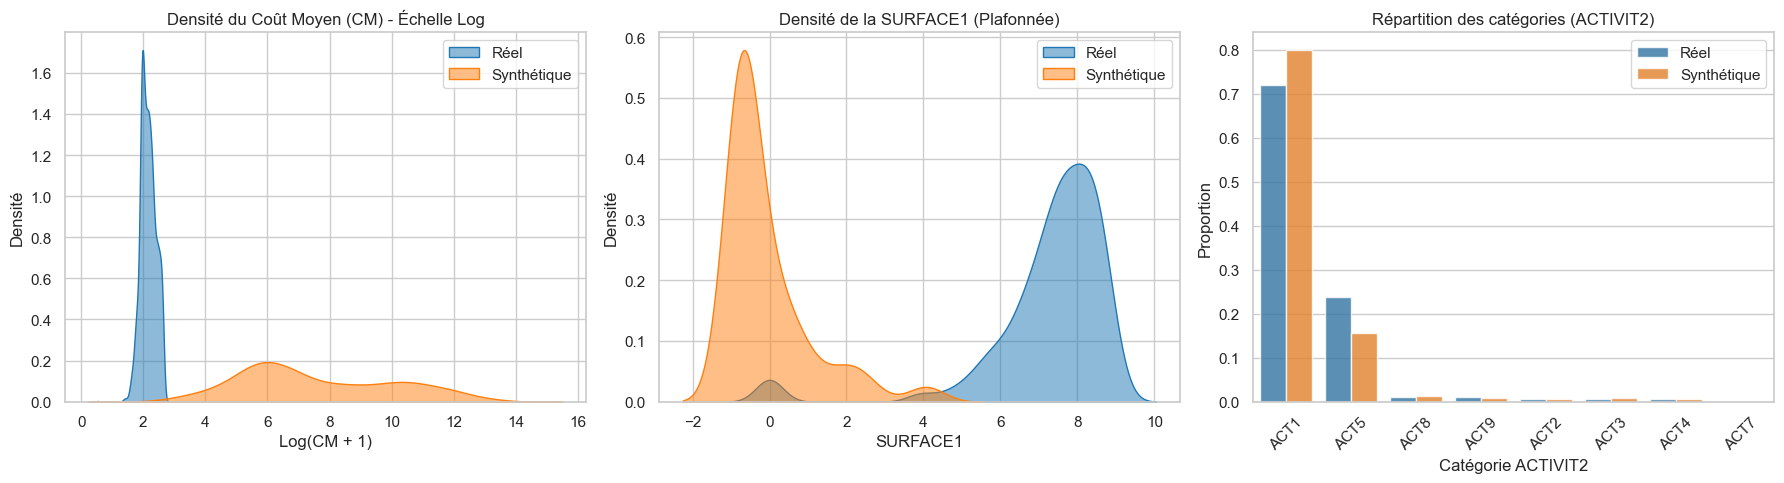

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Configuration du style pour que ça rende bien dans un rapport
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ---------------------------------------------------------
# 1. Histogramme du Coût Moyen (CM) en échelle logarithmique
# ---------------------------------------------------------
# On filtre les valeurs > 0 pour éviter les soucis avec le log
real_cm = df_sinistres[df_sinistres['CM'] > 0]['CM']
fake_cm = synthetic_data[synthetic_data['CM'] > 0]['CM']

sns.kdeplot(np.log1p(real_cm), fill=True, label="Réel", ax=axes[0], color="#1f77b4", alpha=0.5)
sns.kdeplot(np.log1p(fake_cm), fill=True, label="Synthétique", ax=axes[0], color="#ff7f0e", alpha=0.5)
axes[0].set_title("Densité du Coût Moyen (CM) - Échelle Log", fontsize=12)
axes[0].set_xlabel("Log(CM + 1)")
axes[0].set_ylabel("Densité")
axes[0].legend()

# ---------------------------------------------------------
# 2. Histogramme d'une variable de surface (ex: SURFACE1)
# ---------------------------------------------------------
surface_col = 'SURFACE1'
# On limite au 95e percentile pour que le graphique ne soit pas écrasé par quelques valeurs extrêmes
q_max = df_sinistres[surface_col].quantile(0.95)
real_surf = df_sinistres[df_sinistres[surface_col] <= q_max][surface_col]
fake_surf = synthetic_data[synthetic_data[surface_col] <= q_max][surface_col]

sns.kdeplot(real_surf, fill=True, label="Réel", ax=axes[1], color="#1f77b4", alpha=0.5)
sns.kdeplot(fake_surf, fill=True, label="Synthétique", ax=axes[1], color="#ff7f0e", alpha=0.5)
axes[1].set_title(f"Densité de la {surface_col} (Plafonnée)", fontsize=12)
axes[1].set_xlabel(f"{surface_col}")
axes[1].set_ylabel("Densité")
axes[1].legend()

# ---------------------------------------------------------
# 3. Fréquences de la variable catégorielle ACTIVIT2
# ---------------------------------------------------------
# Calcul des proportions pour les données réelles
real_activit = df_sinistres['ACTIVIT2'].value_counts(normalize=True).rename('Proportion').reset_index()
real_activit['Source'] = 'Réel'

# Calcul des proportions pour les données synthétiques
fake_activit = synthetic_data['ACTIVIT2'].value_counts(normalize=True).rename('Proportion').reset_index()
fake_activit['Source'] = 'Synthétique'

# Concaténation et création du barplot
activit_df = pd.concat([real_activit, fake_activit])

sns.barplot(data=activit_df, x='ACTIVIT2', y='Proportion', hue='Source', ax=axes[2], palette=['#1f77b4', '#ff7f0e'], alpha=0.8)
axes[2].set_title("Répartition des catégories (ACTIVIT2)", fontsize=12)
axes[2].set_xlabel("Catégorie ACTIVIT2")
axes[2].set_ylabel("Proportion")
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend(title="")

# Ajustement des espacements
plt.tight_layout()

# Sauvegarde pour le rapport PDF (tu pourras récupérer l'image dans ton dossier)
plt.savefig("validation_ctgan.png", dpi=300, bbox_inches='tight')
plt.show()

=> On passe à 5599